In [1]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Set global academic style for LNCS (serif font, readable sizes)
research_palette = {
    'blue': '#0072B2',
    'orange': '#E69F00',
    'green': '#009E73',
    'red': '#D55E00',
    'purple': '#CC79A7',
    'sky': '#56B4E9',
    'gray': '#6E6E6E',
    'black': '#222222',
}

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.prop_cycle': cycler(color=[
        research_palette['blue'],
        research_palette['orange'],
        research_palette['green'],
        research_palette['red'],
        research_palette['purple'],
        research_palette['sky'],
    ]),
})

# Quantization Stress Test (Grouped Bar Chart)

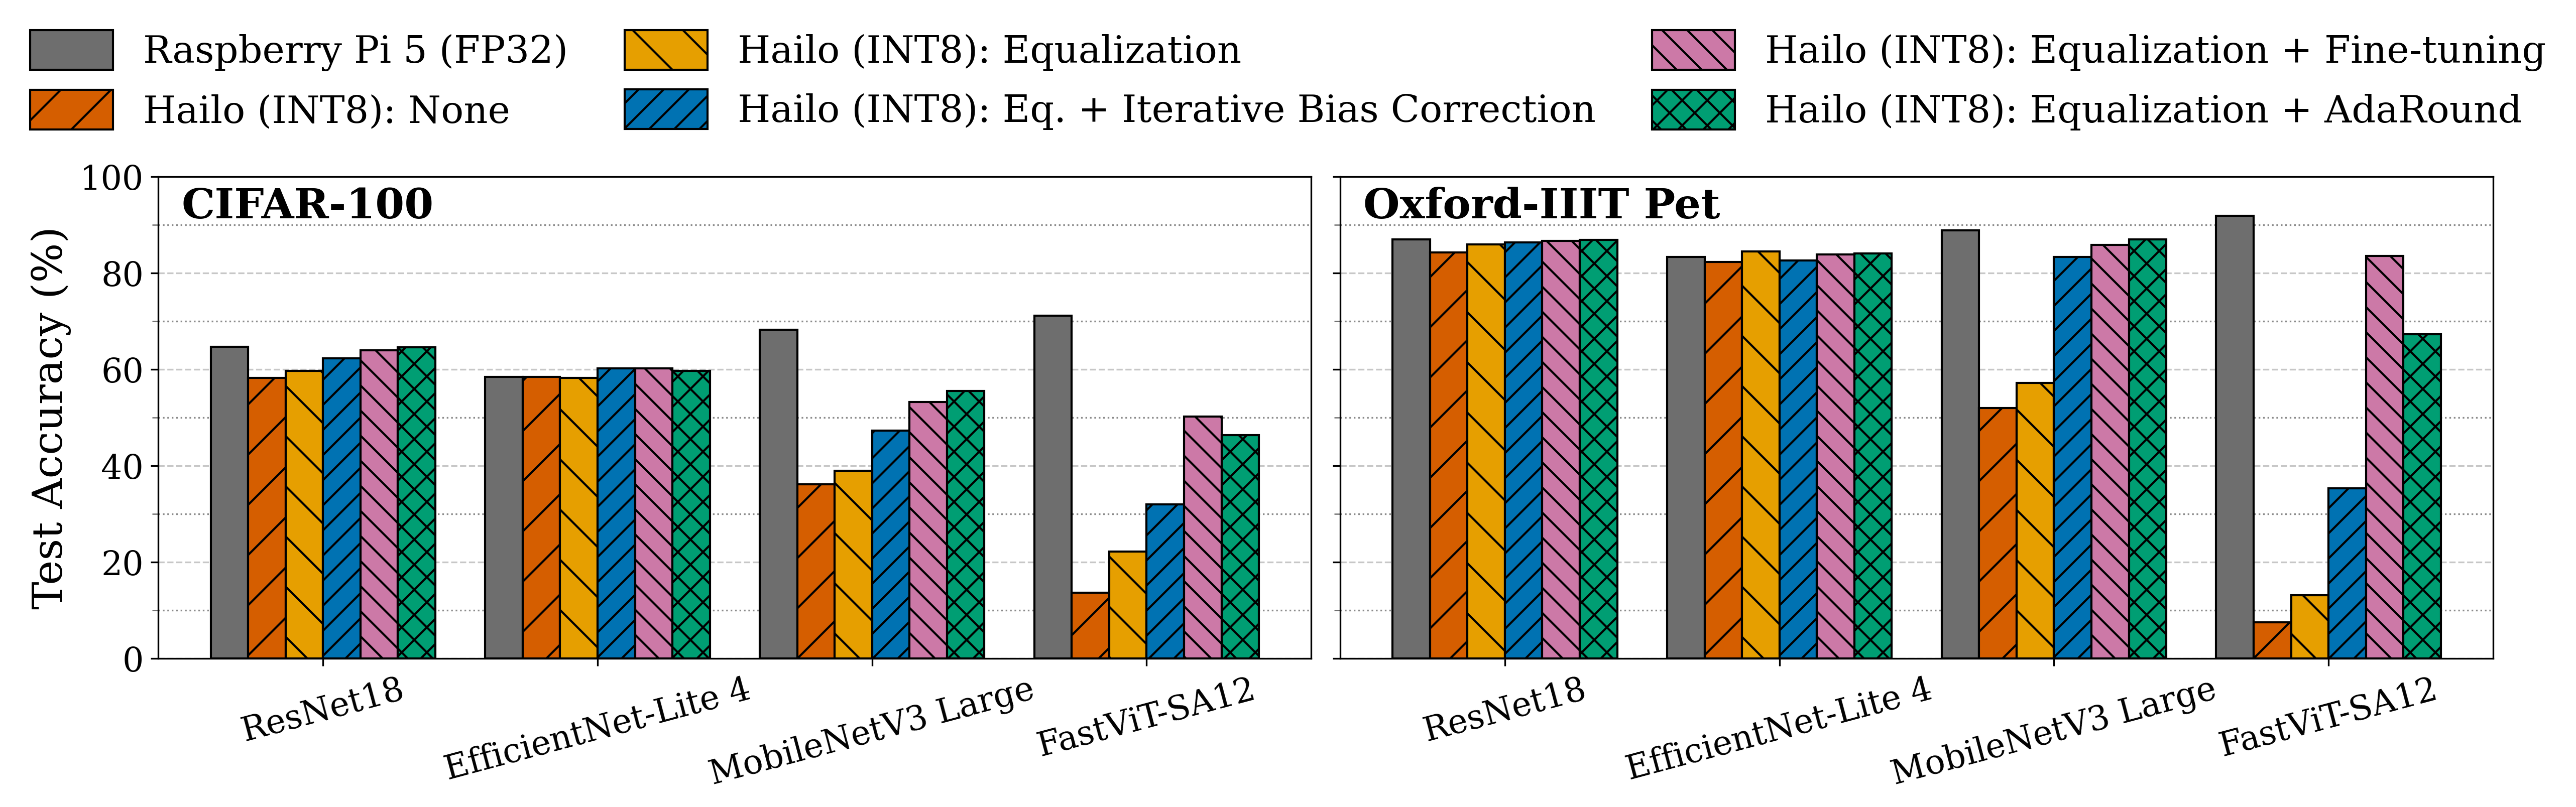

In [2]:
models = ['ResNet18', 'EfficientNet-Lite 4', 'MobileNetV3 Large', 'FastViT-SA12']

# CIFAR100 accuracies for each configuration across the 4 models (0-1 scale)
cifar_base_cpu = [0.6468, 0.5848, 0.6826, 0.7119]
cifar_hailo_none = [0.5829, 0.5850, 0.3615, 0.1371]
cifar_hailo_eq = [0.5974, 0.5822, 0.3903, 0.2220]
cifar_hailo_eq_ibc = [0.6233, 0.6023, 0.4732, 0.3201]
cifar_hailo_eq_finetune = [0.6398, 0.6023, 0.5325, 0.5019]
cifar_hailo_eq_ada = [0.6462, 0.5973, 0.5553, 0.4634]

# Oxford-IIIT Pet accuracies for each configuration across the 4 models (0-1 scale)
pets_base_cpu = [0.8697, 0.8337, 0.8888, 0.9188]
pets_hailo_none = [0.8427, 0.8234, 0.5198, 0.0750]
pets_hailo_eq = [0.8599, 0.8449, 0.5721, 0.1316]
pets_hailo_eq_ibc = [0.8640, 0.8267, 0.8337, 0.3530]
pets_hailo_eq_finetune = [0.8664, 0.8392, 0.8583, 0.8354]
pets_hailo_eq_ada = [0.8694, 0.8408, 0.8700, 0.6727]
# ========================================== #

group_spacing = 1.1
x = np.arange(len(models)) * group_spacing
width = 0.15  # Width of the bars

fig, axs = plt.subplots(1, 2, figsize=(20, 4), sharey=True)

def plot_dataset(ax, title, base_cpu, hailo_none, hailo_eq, hailo_eq_ibc, hailo_eq_finetune, hailo_eq_ada):
    ax.set_axisbelow(True)
    base_cpu_pct = [v * 100 for v in base_cpu]
    hailo_none_pct = [v * 100 for v in hailo_none]
    hailo_eq_pct = [v * 100 for v in hailo_eq]
    hailo_eq_ibc_pct = [v * 100 for v in hailo_eq_ibc]
    hailo_eq_finetune_pct = [v * 100 for v in hailo_eq_finetune]
    hailo_eq_ada_pct = [v * 100 for v in hailo_eq_ada]
    hatch_styles = ['', '/', '\\', '//', '\\\\', 'xx']
    offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width
    ax.bar(x + offsets[0], base_cpu_pct, width, label='Raspberry Pi 5 (FP32)', color=research_palette['gray'], edgecolor='black', hatch=hatch_styles[0])
    ax.bar(x + offsets[1], hailo_none_pct, width, label='Hailo (INT8): None', color=research_palette['red'], edgecolor='black', hatch=hatch_styles[1])
    ax.bar(x + offsets[2], hailo_eq_pct, width, label='Hailo (INT8): Equalization', color=research_palette['orange'], edgecolor='black', hatch=hatch_styles[2])
    ax.bar(x + offsets[3], hailo_eq_ibc_pct, width, label='Hailo (INT8): Eq. + Iterative Bias Correction', color=research_palette['blue'], edgecolor='black', hatch=hatch_styles[3])
    ax.bar(x + offsets[4], hailo_eq_finetune_pct, width, label='Hailo (INT8): Equalization + Fine-tuning', color=research_palette['purple'], edgecolor='black', hatch=hatch_styles[4])
    ax.bar(x + offsets[5], hailo_eq_ada_pct, width, label='Hailo (INT8): Equalization + AdaRound', color=research_palette['green'], edgecolor='black', hatch=hatch_styles[5])
    ax.text(0.02, 0.98, title, transform=ax.transAxes, ha='left', va='top', fontsize=20, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=16, rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels(np.arange(0, 101, 20), fontsize=16)
    ax.set_yticks(np.arange(0, 101, 10), minor=True)
    ax.grid(axis='y', which='minor', linestyle=':', alpha=0.8, linewidth=0.8, color=research_palette['gray'])
    ax.tick_params(axis='y', which='minor', length=3, width=0.6, color=research_palette['gray'])

plot_dataset(
    axs[0],
    'CIFAR-100',
    cifar_base_cpu,
    cifar_hailo_none,
    cifar_hailo_eq,
    cifar_hailo_eq_ibc,
    cifar_hailo_eq_finetune,
    cifar_hailo_eq_ada,
)
plot_dataset(
    axs[1],
    'Oxford-IIIT Pet',
    pets_base_cpu,
    pets_hailo_none,
    pets_hailo_eq,
    pets_hailo_eq_ibc,
    pets_hailo_eq_finetune,
    pets_hailo_eq_ada,
)

axs[0].set_ylabel('Test Accuracy (%)', fontsize=20)

# Shared legend above both plots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.2), columnspacing=1.5, handlelength=2.2, handleheight=1.25, fontsize=18)
fig.subplots_adjust(top=0.9, bottom=0.10, wspace=0.025)

plt.savefig('Figure_X_quantization_performance_restoration.pdf')
plt.show()

# Batch Size & Throughput (Line Plot)

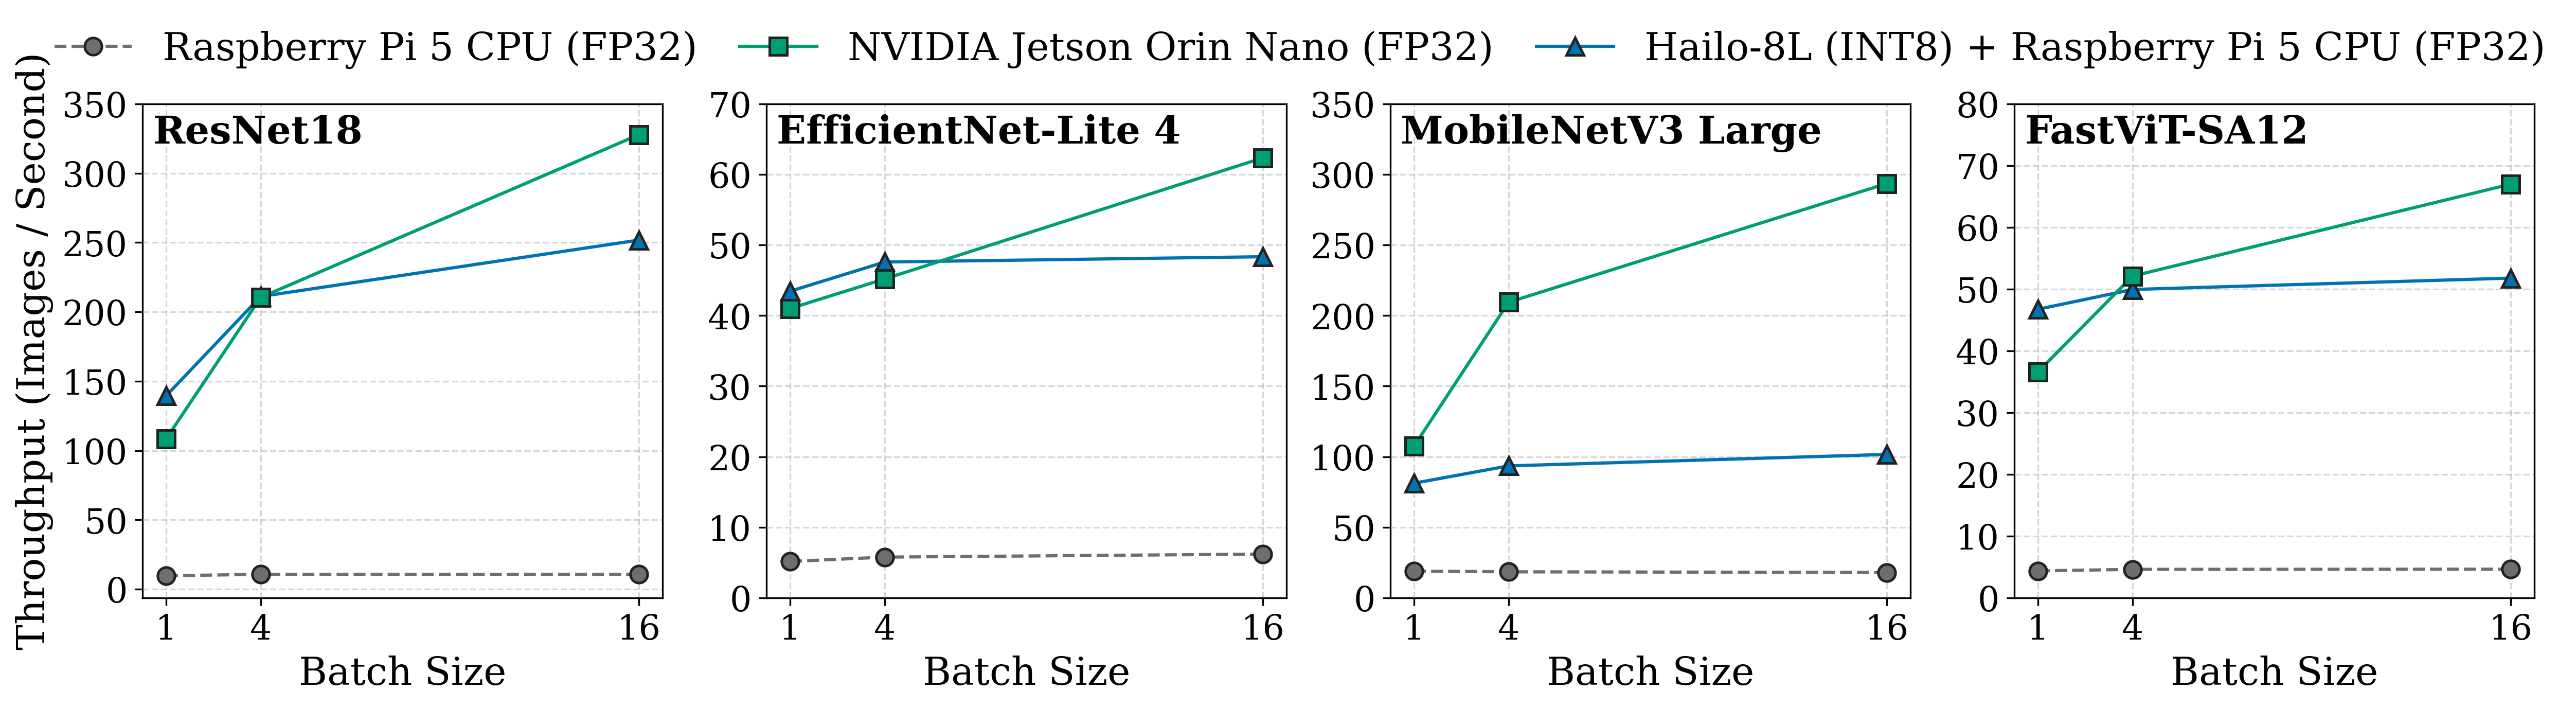

In [5]:
batch_sizes = [1, 4, 16]  # X-axis shared across models
train_samples = 3680

# Avg training time per epoch (seconds)
epoch_time_orin = {
    'ResNet18': [33.9203, 17.4836, 11.2273],
    'EfficientNet-Lite 4': [89.7454, 81.4281, 59.0202],
    'MobileNetV3 Large': [34.2189, 17.5686, 12.5344],
    'FastViT-SA12': [100.5133, 70.6178, 54.924],
}
epoch_time_pi_cpu = {
    'ResNet18': [378.4648, 341.2172, 343.1013],
    'EfficientNet-Lite 4': [713.9768, 637.6677, 593.5879],
    'MobileNetV3 Large': [193.9884, 199.5229, 204.5296],
    'FastViT-SA12': [843.6679, 797.4809, 792.8039],
}
epoch_time_pi_hailo = {
    'ResNet18': [26.3703, 17.4307, 14.6157],
    'EfficientNet-Lite 4': [84.6871, 77.3276, 76.1287],
    'MobileNetV3 Large': [45.2976, 39.3599, 36.2120],
    'FastViT-SA12': [78.7284, 73.6862, 71.0667],
}
# ========================================== #

def epoch_time_to_throughput(epoch_times):
    return [train_samples / t if t > 0 else np.nan for t in epoch_times]

throughput_orin = {model: epoch_time_to_throughput(times) for model, times in epoch_time_orin.items()}
throughput_pi_cpu = {model: epoch_time_to_throughput(times) for model, times in epoch_time_pi_cpu.items()}
throughput_pi_hailo = {model: epoch_time_to_throughput(times) for model, times in epoch_time_pi_hailo.items()}

fig, axs = plt.subplots(1, 4, figsize=(20, 4), sharex=False, sharey=False)

# Plot each model in its own panel
for i, ax in enumerate(axs):
    model_name = models[i] if i < len(models) else f'Model {i+1}'
    orin_vals = throughput_orin.get(model_name, [np.nan] * len(batch_sizes))
    cpu_vals = throughput_pi_cpu.get(model_name, [np.nan] * len(batch_sizes))
    hailo_vals = throughput_pi_hailo.get(model_name, [np.nan] * len(batch_sizes))
    ax.plot(batch_sizes, cpu_vals, marker='o', linestyle='--', color=research_palette['gray'], label='Raspberry Pi 5 CPU (FP32)', markeredgecolor=research_palette['black'], markeredgewidth=1.2, markersize=8)
    ax.plot(batch_sizes, hailo_vals, marker='^', linestyle='-', color=research_palette['blue'], label='Hailo-8L (INT8) + Raspberry Pi 5 CPU (FP32)', markeredgecolor=research_palette['black'], markeredgewidth=1.2, markersize=8)
    ax.plot(batch_sizes, orin_vals, marker='s', linestyle='-', color=research_palette['green'], label='NVIDIA Jetson Orin Nano (FP32)', markeredgecolor=research_palette['black'], markeredgewidth=1.2, markersize=8)
    ax.text(0.02, 0.98, model_name, transform=ax.transAxes, ha='left', va='top', fontsize=18, fontweight='bold')
    ax.set_xticks(batch_sizes)
    ax.set_yticks(np.arange(0, max(max(cpu_vals), max(hailo_vals), max(orin_vals)) * 1.2, 50 if max(max(cpu_vals), max(hailo_vals), max(orin_vals)) > 100 else 10))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

# Shared axis labels
for ax in axs:
    ax.set_xlabel('Batch Size', fontsize=18)
    # ax.set_xscale('log')
axs[0].set_ylabel('Throughput (Images / Second)', fontsize=18)

# Shared legend above first row
handles, labels = axs[0].get_legend_handles_labels()
legend_order = [
    'Raspberry Pi 5 CPU (FP32)',
    'NVIDIA Jetson Orin Nano (FP32)',
    'Hailo-8L (INT8) + Raspberry Pi 5 CPU (FP32)',
]
ordered_handles = [handles[labels.index(name)] for name in legend_order]
fig.legend(ordered_handles, legend_order, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.075), fontsize=18, columnspacing=1.1, handlelength=2)

fig.subplots_adjust(top=0.9, hspace=0.1, wspace=0.2, bottom=0.1)

plt.savefig('Figure_5_throughput_grid.pdf')
plt.show()

# Time-to-Accuracy Convergence (Line Chart)

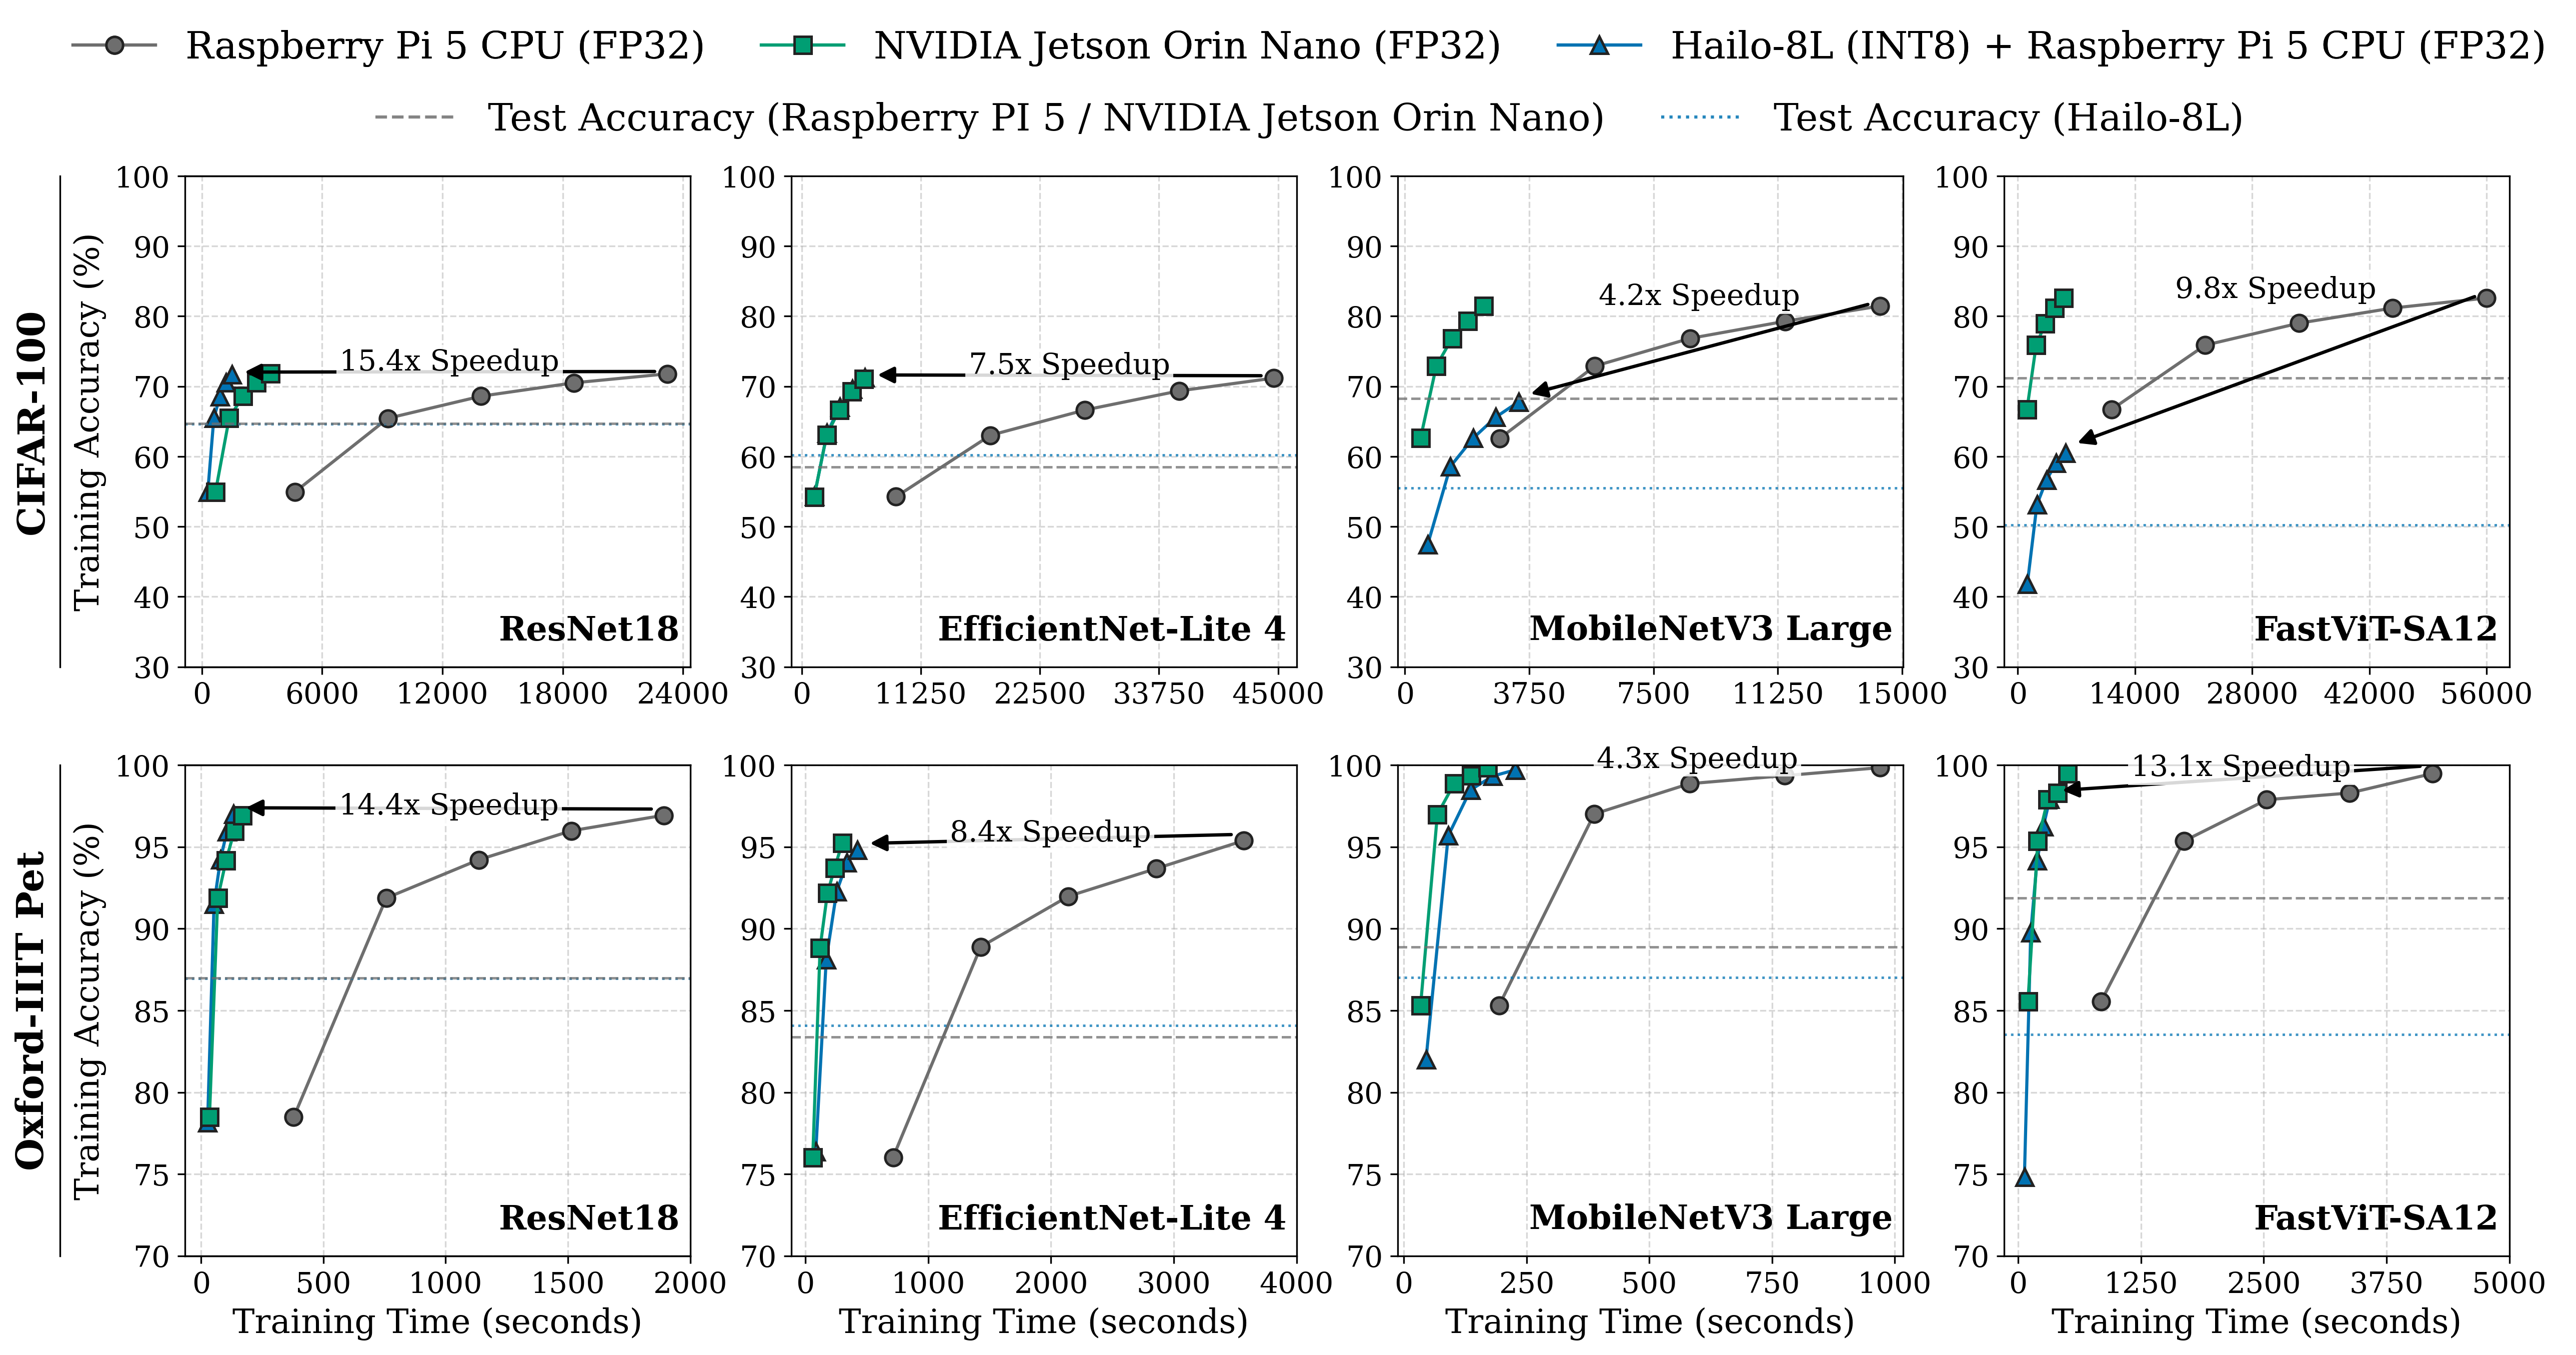

In [4]:
# ==== CIFAR-100 ==== #
epoch_time_cpu = {
    'ResNet18': 4642.2685,
    'EfficientNet-Lite 4': 8914.0879,
    'MobileNetV3 Large': 2866.7361,
    'FastViT-SA12': 11194.6549,
}
acc_cpu = {
    'ResNet18': [0.5492, 0.6544, 0.6859, 0.7050, 0.7178],
    'EfficientNet-Lite 4': [0.5426, 0.6302, 0.6662, 0.6935, 0.7117],
    'MobileNetV3 Large': [0.6259, 0.7289, 0.7683, 0.7927, 0.8145],
    'FastViT-SA12': [0.6669, 0.7587, 0.7900, 0.8116, 0.8259],
}

epoch_time_hailo = {
    'ResNet18': sum([300.7108, 294.6568, 305.9182, 301.0173, 307.4692]) / 5,
    'EfficientNet-Lite 4': sum([1201.7438, 1191.9979, 1197.1582, 1195.3116, 1192.1079]) / 5,
    'MobileNetV3 Large': sum([679.2542, 688.7718, 697.6073, 687.2637, 678.4462]) / 5,
    'FastViT-SA12': sum([1129.7409, 1142.4807, 1141.6916, 1144.7043, 1144.8539]) / 5,
}
acc_hailo = {
    'ResNet18': [0.5493, 0.6545, 0.6853, 0.7055, 0.7169],
    'EfficientNet-Lite 4': [0.5436, 0.6331, 0.6707, 0.6962, 0.7128],
    'MobileNetV3 Large': [0.4741, 0.5856, 0.6260, 0.6561, 0.6779],
    'FastViT-SA12': [0.4182, 0.5312, 0.5663, 0.5904, 0.6049],
}

epoch_time_orin = {
    'ResNet18': 685.2025,
    'EfficientNet-Lite 4': 1178.0616,
    'MobileNetV3 Large': 474.438,
    'FastViT-SA12': 1096.1076,
}
acc_orin = {
    'ResNet18': [0.5492, 0.6546, 0.6859, 0.7053, 0.7180],
    'EfficientNet-Lite 4': [0.5425, 0.6303, 0.6661, 0.6929, 0.7103],
    'MobileNetV3 Large': [0.6262, 0.7288, 0.7684, 0.7930, 0.8144],
    'FastViT-SA12': [0.6670, 0.7586, 0.7898, 0.8116, 0.8260],
}

# Test accuracy placeholders (0-1 scale) for dashed reference lines.
test_acc_hailo = {
    'ResNet18': 0.6462,
    'EfficientNet-Lite 4': 0.6023,
    'MobileNetV3 Large': 0.5553,
    'FastViT-SA12': 0.5019,
}
test_acc_cpu_orin_shared = {
    'ResNet18': 0.6468,
    'EfficientNet-Lite 4': 0.5848,
    'MobileNetV3 Large': 0.6826,
    'FastViT-SA12': 0.7119,
}

# ==== Oxford III Pet ==== #
epoch_time_cpu_pets = {
    'ResNet18': 378.4648,
    'EfficientNet-Lite 4': 713.9768,
    'MobileNetV3 Large': 193.9884,
    'FastViT-SA12': 843.6679,
}
acc_cpu_pets = {
    'ResNet18': [0.7848, 0.9187, 0.9421, 0.9598, 0.9693],
    'EfficientNet-Lite 4': [0.7603, 0.8889, 0.9198, 0.9367, 0.9538],
    'MobileNetV3 Large': [0.8530, 0.9701, 0.9886, 0.9935, 0.9984],
    'FastViT-SA12': [0.8554, 0.9535, 0.9788, 0.9829, 0.9948],
}

epoch_time_hailo_pets = {
    'ResNet18': sum([24.3201, 25.2703, 26.6248, 27.8300, 27.8061]) / 5,
    'EfficientNet-Lite 4': sum([84.1399, 85.0649, 86.7706, 83.6833, 83.7770]) / 5,
    'MobileNetV3 Large': sum([45.1930, 45.6276, 46.0116, 45.3666, 44.2890]) / 5,
    'FastViT-SA12': sum([79.1398, 0.5222, 80.9885, 80.8647, 80.3561]) / 5,
}
acc_hailo_pets = {
    'ResNet18': [0.7815, 0.9152, 0.9424, 0.9595, 0.9701],
    'EfficientNet-Lite 4': [0.7639, 0.8810, 0.9226, 0.9405, 0.9481],
    'MobileNetV3 Large': [0.8201, 0.9568, 0.9848, 0.9932, 0.9970],
    'FastViT-SA12': [0.7481, 0.8976, 0.9416, 0.9625, 0.9791],
}

epoch_time_orin_pets = {
    'ResNet18': 33.9203,
    'EfficientNet-Lite 4': 59.7454,
    'MobileNetV3 Large': 34.2189,
    'FastViT-SA12': 100.5133,
}
acc_orin_pets = {
    'ResNet18': [0.7848, 0.9187, 0.9416, 0.9598, 0.9693],
    'EfficientNet-Lite 4': [0.7601, 0.8883, 0.9217, 0.9372, 0.9522],
    'MobileNetV3 Large': [0.8530, 0.9698, 0.9886, 0.9935, 0.9986],
    'FastViT-SA12': [0.8554, 0.9535, 0.9788, 0.9829, 0.9948],
}

test_acc_cpu_orin_shared_pets = {
    'ResNet18': 0.8697,
    'EfficientNet-Lite 4': 0.8337,
    'MobileNetV3 Large': 0.8888,
    'FastViT-SA12': 0.9188,
}
test_acc_hailo_pets = {
    'ResNet18': 0.8694,
    'EfficientNet-Lite 4': 0.8408,
    'MobileNetV3 Large': 0.8700,
    'FastViT-SA12': 0.8354,
}
# ========================================== #

datasets = [
    {
        'title': 'CIFAR-100',
        'epoch_time_cpu': epoch_time_cpu,
        'acc_cpu': acc_cpu,
        'epoch_time_hailo': epoch_time_hailo,
        'acc_hailo': acc_hailo,
        'epoch_time_orin': epoch_time_orin,
        'acc_orin': acc_orin,
        'test_acc_hailo': test_acc_hailo,
        'test_acc_cpu_orin_shared': test_acc_cpu_orin_shared,
    },
    {
        'title': 'Oxford-IIIT Pet',
        'epoch_time_cpu': epoch_time_cpu_pets,
        'acc_cpu': acc_cpu_pets,
        'epoch_time_hailo': epoch_time_hailo_pets,
        'acc_hailo': acc_hailo_pets,
        'epoch_time_orin': epoch_time_orin_pets,
        'acc_orin': acc_orin_pets,
        'test_acc_hailo': test_acc_hailo_pets,
        'test_acc_cpu_orin_shared': test_acc_cpu_orin_shared_pets,
    },
]

fig, axs = plt.subplots(2, 4, figsize=(20, 8), sharex=False, sharey=False)

for row_idx, dataset in enumerate(datasets):
    for col_idx, model_name in enumerate(models):
        ax = axs[row_idx, col_idx]
        a_cpu = dataset['acc_cpu'].get(model_name, [])
        a_hailo = dataset['acc_hailo'].get(model_name, [])
        a_orin = dataset['acc_orin'].get(model_name, [])
        t_cpu = [dataset['epoch_time_cpu'].get(model_name, 0) * (idx + 1) for idx in range(len(a_cpu))]
        t_hailo = [dataset['epoch_time_hailo'].get(model_name, 0) * (idx + 1) for idx in range(len(a_hailo))]
        t_orin = [dataset['epoch_time_orin'].get(model_name, 0) * (idx + 1) for idx in range(len(a_orin))]
        a_cpu_pct = [v * 100 for v in a_cpu]
        a_hailo_pct = [v * 100 for v in a_hailo]
        a_orin_pct = [v * 100 for v in a_orin]
        ax.plot(t_cpu, a_cpu_pct, marker='o', linestyle='-', color=research_palette['gray'], label='Raspberry Pi 5 CPU (FP32)', markeredgecolor=research_palette['black'], markeredgewidth=1.2, markersize=8)
        ax.plot(t_hailo, a_hailo_pct, marker='^', linestyle='-', color=research_palette['blue'], label='Hailo-8L (INT8) + Raspberry Pi 5 CPU (FP32)', markeredgecolor=research_palette['black'], markeredgewidth=1.2, markersize=8)
        ax.plot(t_orin, a_orin_pct, marker='s', linestyle='-', color=research_palette['green'], label='NVIDIA Jetson Orin Nano (FP32)', markeredgecolor=research_palette['black'], markeredgewidth=1.2, markersize=8)
        ax.text(0.98, 0.04, model_name, transform=ax.transAxes, ha='right', va='bottom', fontsize=16, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        max_time = max([0] + t_cpu + t_hailo + t_orin) // 1000 * 1000 + 1000
        if max_time > 0:
            ax.set_xticks(np.linspace(0, max_time, 5))
        if row_idx == 0:
            ax.set_ylim(30, 100)
            ax.set_yticks(np.arange(30, 101, 10))
            ax.set_yticklabels(np.arange(30, 101, 10))
        else:
            ax.set_ylim(70, 100)
            ax.set_yticks(np.arange(70, 101, 5))
            ax.set_yticklabels(np.arange(70, 101, 5))
        # Set x-axis fontsize for all subplots
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        # Reference lines for test accuracy (Hailo and shared CPU/Orin).
        hailo_test = dataset['test_acc_hailo'].get(model_name)
        shared_test = dataset['test_acc_cpu_orin_shared'].get(model_name)
        if hailo_test is not None:
            ax.axhline(hailo_test * 100, linestyle=':', color=research_palette['blue'], alpha=0.75, linewidth=1.2)
        if shared_test is not None:
            ax.axhline(shared_test * 100, linestyle='--', color=research_palette['gray'], alpha=0.75, linewidth=1.2)

        # Compute per-model speedup using the final markers for each curve.
        if t_cpu and a_cpu_pct and t_hailo and a_hailo_pct:
            t_cpu_last = t_cpu[-1]
            a_cpu_last = a_cpu_pct[-1]
            t_hailo_last = t_hailo[-1]
            a_hailo_last = a_hailo_pct[-1]
            if t_hailo_last > 0:
                speedup = t_cpu_last / t_hailo_last
                y_min = min(min(a_cpu_pct), min(a_hailo_pct))
                y_max = max(max(a_cpu_pct), max(a_hailo_pct))
                y_range = max(y_max - y_min, 1e-6)
                y_offset = 0.02 * y_range
                y_start = a_hailo_last + y_offset
                y_end = a_cpu_last + y_offset
                x_mid = (t_hailo_last + t_cpu_last) / 2
                y_text = min(max(y_start, y_end) + 0.11 * y_range, y_max - 0.02 * y_range)
                ax.annotate(
                    '',
                    xy=(t_hailo_last, y_start),
                    xytext=(t_cpu_last, y_end),
                    arrowprops=dict(arrowstyle='-|>', color='black', lw=1.6, mutation_scale=16, shrinkA=6, shrinkB=6),
                )
                ax.text(
                    x_mid,
                    y_text,
                    f'{speedup:.1f}x Speedup',
                    ha='center',
                    va='bottom',
                    zorder=5,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5),
                    fontsize=14,
                )

# Shared axis labels
for ax in axs[1, :]:
    ax.set_xlabel('Training Time (seconds)', fontsize=16)
for ax in axs[:, 0]:
    ax.set_ylabel('Training Accuracy (%)', fontsize=16)

# Dataset labels as secondary y-axis labels on the left
for row_idx, dataset in enumerate(datasets):
    dataset_axis = axs[row_idx, 0].twinx()
    dataset_axis.spines['right'].set_visible(False)
    dataset_axis.spines['left'].set_position(('outward', 60))
    dataset_axis.yaxis.set_label_position('left')
    dataset_axis.yaxis.tick_left()
    dataset_axis.set_yticks([])
    dataset_axis.set_ylabel(dataset['title'], fontsize=18, fontweight='bold')

# Shared legend between rows (centered)
handles, labels = axs[0, 0].get_legend_handles_labels()
main_order = [
    'Raspberry Pi 5 CPU (FP32)',
    'NVIDIA Jetson Orin Nano (FP32)',
    'Hailo-8L (INT8) + Raspberry Pi 5 CPU (FP32)',
]
main_handles = [handles[labels.index(name)] for name in main_order]
dash_handles = [
    plt.Line2D([0], [0], color=research_palette['gray'], linestyle='--', lw=1.5, alpha=0.85),
    plt.Line2D([0], [0], color=research_palette['blue'], linestyle=':', lw=1.5, alpha=0.85),
]
dash_labels = [ 'Test Accuracy (Raspberry PI 5 / NVIDIA Jetson Orin Nano)', 'Test Accuracy (Hailo-8L)']
legend_main = fig.legend(
    main_handles,
    main_order,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.15),
    fontsize=18,
    columnspacing=1.5,
    handlelength=2.2,
)
fig.legend(
    dash_handles,
    dash_labels,
    loc='upper center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.09),
    fontsize=18,
    columnspacing=1.5,
    handlelength=2.2,
)
fig.add_artist(legend_main)

fig.subplots_adjust(top=1.0, hspace=0.2, wspace=0.2, bottom=0.1)

plt.savefig('Figure_X_convergence_grid.pdf')
plt.show()